# Experiment No. 08 - Random Forest and Boosting Comparison

**Course:** CS305 Machine Learning  
**Student:** Mayank Jangid (24/CS/276)  
**Dataset:** Housing.csv  
**Problem type:** House-price regression

## Aim and objectives

Implement and compare **Decision Tree, Random Forest, AdaBoost, and Gradient Boosting regression models** on the housing dataset.

The experiment studies:

- ensemble learning, bagging, and boosting;
- 5-fold cross-validation performance and stability;
- model training time;
- hold-out RMSE, MAE, and $R^2$;
- feature importance; and
- the most suitable model based on performance, stability, speed, and interpretability.

## Theory

- **Decision Tree:** divides the feature space using decision rules. It is easy to understand but can overfit.
- **Random Forest (bagging):** trains many trees on bootstrap samples and random feature subsets, then averages their predictions. Averaging reduces variance.
- **AdaBoost (boosting):** trains weak learners sequentially and gives greater attention to observations with larger earlier errors.
- **Gradient Boosting:** adds trees sequentially, with each new tree learning to reduce the current model's residual errors.

For true values $y_i$ and predictions $\hat{y}_i$:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$$

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

Lower RMSE and MAE are better. A higher $R^2$ is better. A lower cross-validation RMSE standard deviation indicates more stable performance across folds.

## Pseudo algorithm

1. Load and inspect the housing dataset.
2. Identify `price` as the target and all remaining columns as features.
3. Check missing values and duplicate rows.
4. Split the data into training and testing sets.
5. Impute numeric and categorical values and one-hot encode categorical features.
6. Create Decision Tree, Random Forest, AdaBoost, and Gradient Boosting regressors.
7. Apply 5-fold cross-validation on the training set.
8. Record mean RMSE, RMSE standard deviation, mean $R^2$, and training time.
9. Fit every model on the complete training set and evaluate it on the test set.
10. Extract and compare feature importance from Random Forest and Gradient Boosting.
11. Recommend a model using performance, stability, speed, and interpretability.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("Housing.csv")
TARGET = "price"
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

## 2. Load and inspect the data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Duplicate rows: {df.duplicated().sum()}")
display(df.head())

Dataset shape: 545 rows x 13 columns
Duplicate rows: 0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Observation:** The supplied dataset contains **545 houses and 13 columns**, including the target `price`. It contains **no duplicate rows**.

### 2.1 Data types and missing values

In [3]:
column_summary = pd.DataFrame(
    {
        "Data type": df.dtypes.astype(str),
        "Missing values": df.isna().sum(),
        "Unique values": df.nunique(),
    }
)

display(column_summary)
print(f"Total missing values: {df.isna().sum().sum()}")

,Data type,Missing values,Unique values
price,int64,0,219
area,int64,0,284
bedrooms,int64,0,6
bathrooms,int64,0,4
stories,int64,0,4
mainroad,object,0,2
guestroom,object,0,2
basement,object,0,2
hotwaterheating,object,0,2
airconditioning,object,0,2


Total missing values: 0


**Observation:** There are **no missing values** in the supplied file. The preprocessing pipeline still includes imputation so that the notebook remains robust if a future row contains a missing value. Yes/no and furnishing columns are categorical and will be one-hot encoded.

### 2.2 Numeric summary and target distribution

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


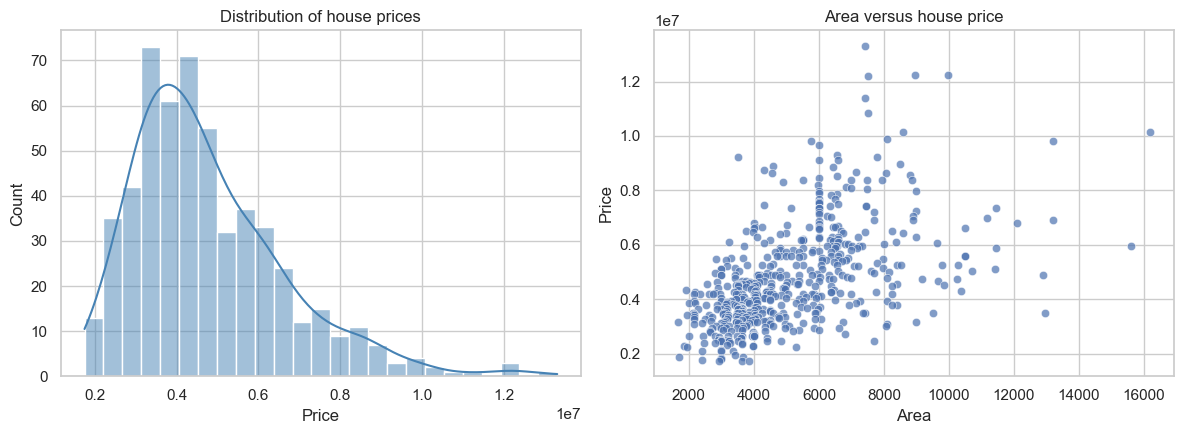

In [4]:
display(df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df[TARGET], bins=25, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of house prices")
axes[0].set_xlabel("Price")

sns.scatterplot(data=df, x="area", y=TARGET, ax=axes[1], alpha=0.7)
axes[1].set_title("Area versus house price")
axes[1].set_xlabel("Area")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

**Observation:** House prices are right-skewed because a small number of houses are much more expensive than the majority. Price generally increases with area, although houses with similar areas can have different prices because other characteristics also matter.

## 3. Prepare the data

In [5]:
X = df.drop(columns=TARGET)
y = df[TARGET]

numeric_features = X.select_dtypes(exclude="object").columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Numeric features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Training rows: 436
Testing rows: 109


The fixed random seed makes the **436-row training set** and **109-row testing set** reproducible. Imputation and one-hot encoding are placed inside each model pipeline, so every cross-validation fold learns preprocessing only from its own training portion and avoids data leakage.

## 4. Create the regression models

In [6]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "AdaBoost": AdaBoostRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model),
        ]
    )
    for name, model in models.items()
}

list(pipelines)

['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting']

**Prediction before training:** The unrestricted Decision Tree is expected to have the highest variance. Random Forest should improve stability through averaging, while Gradient Boosting is expected to achieve strong predictive performance by correcting residual errors sequentially.

## 5. Compare models using 5-fold cross-validation

In [7]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_rows = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    fold_rmse = -scores["test_RMSE"]
    cv_rows.append(
        {
            "Model": name,
            "CV RMSE Mean": fold_rmse.mean(),
            "CV RMSE Std": fold_rmse.std(),
            "CV R2 Mean": scores["test_R2"].mean(),
            "CV R2 Std": scores["test_R2"].std(),
            "Mean Fit Time (s)": scores["fit_time"].mean(),
        }
    )

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("CV RMSE Mean")
    .reset_index(drop=True)
)

display(
    cv_results.style.format(
        {
            "CV RMSE Mean": "{:,.0f}",
            "CV RMSE Std": "{:,.0f}",
            "CV R2 Mean": "{:.3f}",
            "CV R2 Std": "{:.3f}",
            "Mean Fit Time (s)": "{:.4f}",
        }
    )
)

,Model,CV RMSE Mean,CV RMSE Std,CV R2 Mean,CV R2 Std,Mean Fit Time (s)
0,Gradient Boosting,"1,075,140","71,752",0.615,0.046,0.0282
1,Random Forest,"1,089,490","74,417",0.601,0.075,0.0602
2,AdaBoost,"1,171,384","82,290",0.544,0.040,0.0517
3,Decision Tree,"1,523,288","206,229",0.198,0.278,0.0054


**Observation:** Gradient Boosting gives the lowest mean CV RMSE (about **1,075,140**) and the highest mean CV $R^2$ (**0.615**). Random Forest is close, with mean RMSE about **1,089,490**. The single Decision Tree has both the largest mean error and the largest variation between folds, which indicates unstable generalisation.

### 5.1 Visual comparison of performance, stability, and time

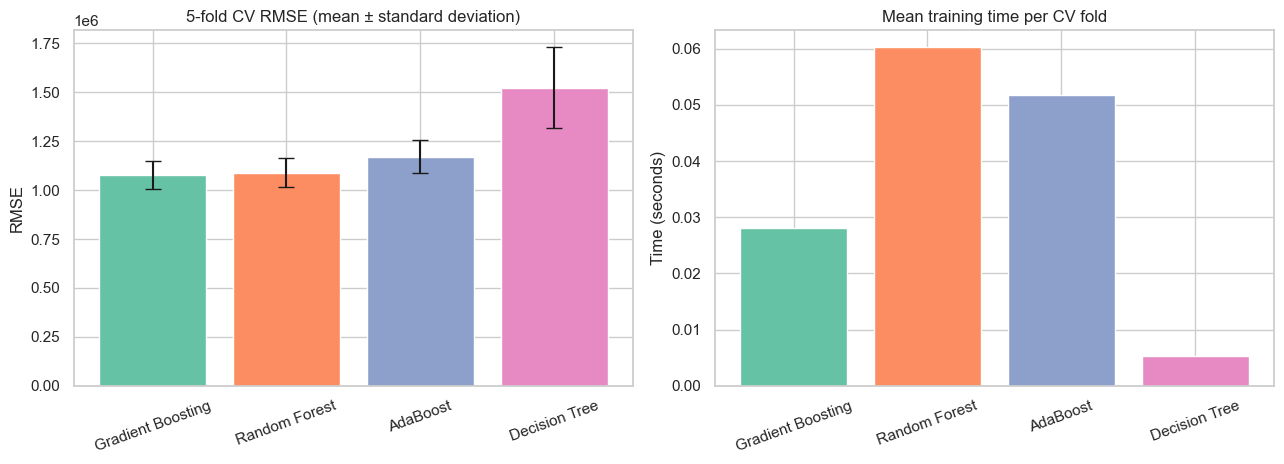

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(
    cv_results["Model"],
    cv_results["CV RMSE Mean"],
    yerr=cv_results["CV RMSE Std"],
    capsize=6,
    color=sns.color_palette("Set2", len(cv_results)),
)
axes[0].set_title("5-fold CV RMSE (mean ± standard deviation)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    cv_results["Model"],
    cv_results["Mean Fit Time (s)"],
    color=sns.color_palette("Set2", len(cv_results)),
)
axes[1].set_title("Mean training time per CV fold")
axes[1].set_ylabel("Time (seconds)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Observation:** Gradient Boosting and Random Forest are much more accurate and stable than one unrestricted Decision Tree. The Decision Tree is fastest, while the ensemble models require additional computation because they train many trees. Training time is machine-dependent and should be interpreted relative to the other models in the same run.

## 6. Evaluate fitted models on the test set

In [9]:
test_rows = []
fitted_models = {}
test_predictions = {}

for name, pipeline in pipelines.items():
    fitted_pipeline = clone(pipeline)
    fitted_pipeline.fit(X_train, y_train)
    predictions = fitted_pipeline.predict(X_test)

    fitted_models[name] = fitted_pipeline
    test_predictions[name] = predictions
    test_rows.append(
        {
            "Model": name,
            "Test RMSE": root_mean_squared_error(y_test, predictions),
            "Test MAE": mean_absolute_error(y_test, predictions),
            "Test R2": r2_score(y_test, predictions),
        }
    )

test_results = (
    pd.DataFrame(test_rows)
    .sort_values("Test RMSE")
    .reset_index(drop=True)
)

display(
    test_results.style.format(
        {
            "Test RMSE": "{:,.0f}",
            "Test MAE": "{:,.0f}",
            "Test R2": "{:.3f}",
        }
    )
)

,Model,Test RMSE,Test MAE,Test R2
0,Gradient Boosting,"1,328,978","973,497",0.651
1,Random Forest,"1,404,075","1,025,824",0.610
2,AdaBoost,"1,577,006","1,213,957",0.508
3,Decision Tree,"1,699,626","1,234,858",0.428


**Observation:** Gradient Boosting also performs best on the held-out test set, with RMSE about **1,328,978**, MAE about **973,497**, and $R^2$ about **0.651**. The test set was not used for cross-validation or model selection, so it provides an independent final check.

## 7. Compare feature importance

,Feature,Importance - Random Forest,Importance - Gradient Boosting
0,area,0.466,0.451
1,bathrooms,0.151,0.183
2,airconditioning,0.063,0.100
3,parking,0.055,0.049
6,bedrooms,0.047,0.045
5,stories,0.054,0.043
7,basement,0.034,0.030
4,furnishingstatus,0.054,0.030
8,prefarea,0.032,0.025
11,mainroad,0.010,0.017


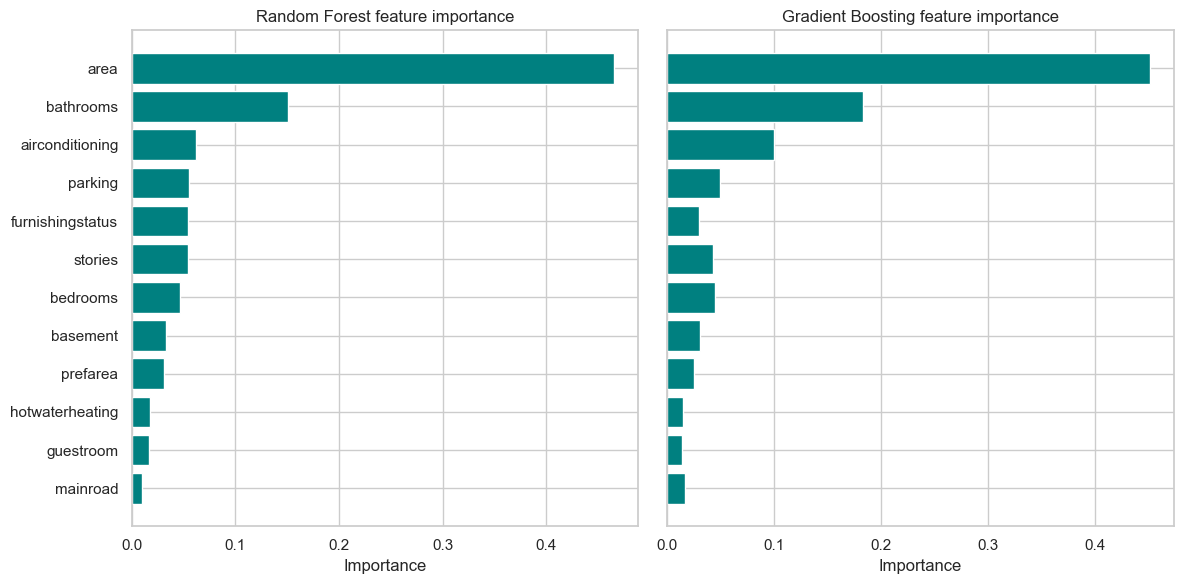

In [10]:
def aggregate_feature_importance(fitted_pipeline):
    """Combine one-hot category importances into original feature names."""
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    importance = fitted_pipeline.named_steps["model"].feature_importances_

    rows = []
    position = 0

    for feature in numeric_features:
        rows.append({"Feature": feature, "Importance": importance[position]})
        position += 1

    encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    for feature, categories in zip(categorical_features, encoder.categories_):
        width = len(categories)
        rows.append(
            {
                "Feature": feature,
                "Importance": importance[position : position + width].sum(),
            }
        )
        position += width

    return (
        pd.DataFrame(rows)
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )


rf_importance = aggregate_feature_importance(fitted_models["Random Forest"])
gb_importance = aggregate_feature_importance(fitted_models["Gradient Boosting"])

importance_comparison = rf_importance.merge(
    gb_importance,
    on="Feature",
    suffixes=(" - Random Forest", " - Gradient Boosting"),
).sort_values("Importance - Gradient Boosting", ascending=False)

display(importance_comparison.style.format("{:.3f}", subset=importance_comparison.columns[1:]))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for axis, title, values in [
    (axes[0], "Random Forest", rf_importance),
    (axes[1], "Gradient Boosting", gb_importance),
]:
    ordered = values.sort_values("Importance")
    axis.barh(ordered["Feature"], ordered["Importance"], color="teal")
    axis.set_title(f"{title} feature importance")
    axis.set_xlabel("Importance")

plt.tight_layout()
plt.show()

**Observation:** Both ensemble models identify **area** as the most influential feature, followed by **bathrooms**. Air conditioning, parking, bedrooms, and stories also contribute. Feature importance shows how strongly a feature helped the fitted trees reduce error; it does not prove that the feature causes a change in price.

## 8. Select and inspect the final model

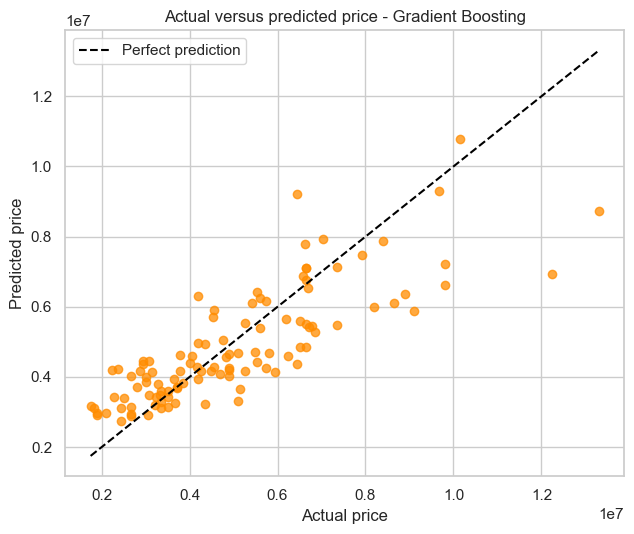

Selected model: Gradient Boosting


In [11]:
best_model_name = cv_results.loc[0, "Model"]
best_predictions = test_predictions[best_model_name]

minimum_value = min(y_test.min(), best_predictions.min())
maximum_value = max(y_test.max(), best_predictions.max())

plt.figure(figsize=(6.5, 5.5))
plt.scatter(y_test, best_predictions, alpha=0.75, color="darkorange")
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="black",
    label="Perfect prediction",
)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Actual versus predicted price - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Selected model: {best_model_name}")

**Final recommendation:** **Gradient Boosting** is selected because it has the lowest cross-validation RMSE, the strongest mean cross-validation $R^2$, low fold-to-fold variation, and the best hold-out result. Random Forest is a strong alternative when parallel training, robustness through averaging, or its bagging interpretation is preferred. A single Decision Tree remains the easiest model to explain, but its weaker and less stable predictions make it unsuitable here as the final model.

## Viva preparation

1. **What is ensemble learning?**  
   It combines predictions from multiple models to produce a stronger final prediction.

2. **What is the difference between bagging and boosting?**  
   Bagging trains models independently on different samples and averages them. Boosting trains models sequentially so later learners correct earlier errors.

3. **How does Random Forest reduce overfitting compared with a single Decision Tree?**  
   It averages many decorrelated trees trained on bootstrap samples and random feature subsets, reducing variance.

4. **Why do we use multiple trees in Random Forest?**  
   Averaging many trees makes predictions more stable and less dependent on one particular training sample.

5. **What is the main idea behind boosting?**  
   Build weak learners sequentially and combine them so each new learner improves the current prediction.

6. **What is the difference between AdaBoost and Gradient Boosting?**  
   AdaBoost changes the attention given to poorly predicted observations, whereas Gradient Boosting fits new learners to the loss gradient, which corresponds to residual errors for squared-error regression.

7. **Why is cross-validation used in this experiment?**  
   It evaluates each model on several train-validation splits and gives a more reliable estimate than a single split.

8. **What does the standard deviation of cross-validation scores tell us?**  
   It measures how much performance changes across folds. A lower value indicates greater stability.

9. **What is feature importance in a tree-based model?**  
   It is the relative contribution of a feature to reducing the model's split criterion across its trees.

10. **Which model would you choose for deployment?**  
    For this experiment, Gradient Boosting is preferred because it gives the best cross-validation and test performance with good stability. The choice can change if interpretability or training cost is more important than prediction quality.

## 9. Conclusion

Decision Tree, Random Forest, AdaBoost, and Gradient Boosting regressors were successfully implemented on `Housing.csv`. Five-fold cross-validation showed that the ensemble methods were more accurate and stable than a single unrestricted tree. **Gradient Boosting** achieved the best overall performance and was selected as the final model. Feature-importance analysis showed that area and bathrooms were the strongest predictors, while the final choice also considered stability, training time, and interpretability rather than error alone.